# Práctica 1 — Model Algorithmic Control (MAC)

En esta práctica el bucle de control predictivo se implementa explícitamente para que puedan observarse:

1. el modelo impulsional FIR;
2. la respuesta libre y la respuesta forzada;
3. la construcción de las matrices $G$ y $F$;
4. la función objetivo;
5. la ley de control;
6. el horizonte deslizante;
7. el efecto de $\lambda$, $N_t$ y del filtrado de referencia.



> **Dinámica recomendada:** antes de ejecutar cada experimento, analice la pregunta asociada y realice una predicción cualitativa. Después, ejecute la celda, compare el resultado con la predicción y despliegue la respuesta razonada.  
> Las respuestas están ocultas en bloques desplegables para poder relizar un análisis pausado.


## Objetivos

Al finalizar la práctica se debería ser capaz de:

- obtener un modelo discreto de una planta continua;
- obtener los coeficientes $h_i$ de un modelo impulsional;
- comprender el significado del truncamiento $N_t$;
- construir el predictor MAC

\begin{align*}
\hat{\mathbf y}=G\mathbf u^+ + \mathbf f,
\end{align*}

con

\begin{align*}
\mathbf f = F\mathbf u^- + \mathbf 1\, y(k);
\end{align*}

- obtener la ley de control MAC sin restricciones;
- implementar el principio de **horizonte deslizante**;
- analizar el error estacionario característico del MAC al penalizar $u$;
- estudiar el efecto de $\lambda$, $N_t$ y del filtro de referencia.

## 1. Librerías

Se utilizan únicamente `NumPy`, `SciPy` y `Matplotlib`, disponibles de forma estándar en Google Colab.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

np.set_printoptions(precision=5, suppress=True)

## 2. Descripción del proceso

El proceso es el control de nivel de un tanque.

![My Image](https://github.com/GICI-UPV-EHU/Imagenes_GICI/blob/main/Procesos/Tanque.png?raw=true)

El balance de caudales es

\begin{align*}
A_t\frac{dh(t)}{dt}=q(t)-q_1(t),
\end{align*}

y, suponiendo flujo laminar,

\begin{align*}
q_1(t)=K_t h(t).
\end{align*}

Por tanto,

\begin{align*}
A_t\frac{dh(t)}{dt}+K_t h(t)=q(t),
\end{align*}

y la función de transferencia entre el caudal de entrada y la altura es

\begin{align*}
G(s)=\frac{H(s)}{Q(s)}
     =\frac{1}{A_t s+K_t}.
\end{align*}

Se establecen unos parámetros del tanque

\begin{align*}
A_t=1,\qquad K_t=0.5,
\end{align*}

se obtiene la siguente función de transferencia

\begin{align*}
\boxed{G(s)=\frac{1}{s+0.5}}.
\end{align*}



In [ ]:
# Parámetros del tanque
At = 1.0
Kt = 0.5

# G(s) = 1 / (At*s + Kt)
G_cont = signal.TransferFunction([1.0], [At, Kt])

print("Modelo continuo:")
print(G_cont)

Modelo continuo:
TransferFunctionContinuous(
array([1.]),
array([1. , 0.5]),
dt: None
)



### Preguntas para dinamizar — interpretación física del proceso

> **Pregunta 1.** Sin hacer ningún cálculo, ¿qué ocurrirá con la altura si mantenemos constante el caudal de entrada? ¿Crecerá indefinidamente?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No. El caudal de salida aumenta con el nivel según $q_1(t)=K_t h(t)$. Se alcanza un equilibrio cuando el caudal de entrada y el de salida son iguales:

\begin{align*}
q=q_1=K_t h.
\end{align*}

Por tanto,

\begin{align*}
h_{\mathrm{eq}}=\frac{q}{K_t}.
\end{align*}

Con $K_t=0.5$, un caudal constante $q=1$ conduce a $h_{\mathrm{eq}}=2$.

Esta pregunta permite anticipar físicamente la ganancia estática antes de calcularla formalmente.

</details>

> **Pregunta 2.** Si duplicamos el área del tanque $A_t$ pero mantenemos $K_t$, ¿cambia la altura final alcanzada ante un mismo caudal? ¿Y la velocidad de respuesta?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

La altura estacionaria no cambia, porque la ganancia estática es

\begin{align*}
G(0)=\frac{1}{K_t}.
\end{align*}

Sin embargo, sí cambia la velocidad de respuesta. La constante de tiempo del proceso es

\begin{align*}
\tau=\frac{A_t}{K_t}.
\end{align*}

Por tanto, duplicar $A_t$ duplica $\tau$: el tanque responde más lentamente.

El objetivo de la pregunta es separar claramente los conceptos de **ganancia estática** y **dinámica**.

</details>

> **Pregunta 3.** ¿Qué sucede si aumentamos $K_t$? Intentad predecir tanto el valor final como la rapidez de la respuesta.

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Para

\begin{align*}
G(s)=\frac{1}{A_t s+K_t},
\end{align*}

la ganancia estática y la constante de tiempo son

\begin{align*}
K=\frac{1}{K_t},
\qquad
\tau=\frac{A_t}{K_t}.
\end{align*}

Al aumentar $K_t$, disminuye la altura estacionaria alcanzada ante un mismo caudal y también disminuye la constante de tiempo. Por tanto, el tanque alcanza una altura menor y lo hace más rápidamente.

</details>


## 3. Discretización

Se establece el siguiente tiempo de muestreo

\begin{align*}
T_d=0.2.
\end{align*}

Se empleará discretización exacta con retenedor de orden cero (ZOH).

Para facilitar posteriormente la simulación en lazo cerrado, representaremos el sistema como

\begin{align*}
x(k+1)&=A_d x(k)+B_d u(k), \\
y(k)&=C_d x(k)+D_d u(k).
\end{align*}

Que es la representación en espacio de estados, pero se emplea simplemente por comodidad de posteriores desarrollos.

In [ ]:
Td = 0.2  # periodo de muestreo

A = np.array([[-Kt / At]])
B = np.array([[1.0 / At]])
C = np.array([[1.0]])
D = np.array([[0.0]])

Ad, Bd, Cd, Dd, _ = signal.cont2discrete((A, B, C, D), Td, method="zoh")

# El sistema es escalar: extraemos escalares para hacer el código más legible.
Ad = float(Ad[0, 0])
Bd = float(Bd[0, 0])
Cd = float(Cd[0, 0])
Dd = float(Dd[0, 0])

print(f"Td = {Td}")
print(f"Ad = {Ad:.8f}")
print(f"Bd = {Bd:.8f}")
print(f"Cd = {Cd:.8f}")
print(f"Dd = {Dd:.8f}")
print()
print("Ecuación discreta:")
print(f"h(k+1) = {Ad:.8f} h(k) + {Bd:.8f} q(k)")

Td = 0.2
Ad = 0.90483742
Bd = 0.19032516
Cd = 1.00000000
Dd = 0.00000000

Ecuación discreta:
h(k+1) = 0.90483742 h(k) + 0.19032516 q(k)



### Preguntas para dinamizar — elección del periodo de muestreo

Para este proceso,

\begin{align*}
\tau=\frac{A_t}{K_t}=2.
\end{align*}

Con $T_d=0.2$ se tienen aproximadamente 10 muestras por constante de tiempo.

> **Pregunta 4.** ¿Os parece $T_d=0.2$ un valor razonable? ¿Cómo podríamos justificarlo antes de realizar ninguna simulación?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Sí, como criterio práctico para esta planta. Se cumple

\begin{align*}
\frac{\tau}{T_d}=\frac{2}{0.2}=10,
\end{align*}

por lo que disponemos de unas 10 muestras por constante de tiempo. Esto proporciona una resolución temporal suficiente para describir la dinámica dominante sin aumentar innecesariamente el coste de cálculo.

No debe interpretarse como una regla universal de diseño.

</details>

> **Pregunta 5.** ¿Qué creéis que ocurrirá si cambiamos `Td = 0.2` por `Td = 1.0`? Antes de ejecutar, predecid qué sucederá con $A_d$, con $B_d$ y con la resolución temporal del modelo.

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Para este sistema de primer orden,

\begin{align*}
A_d=e^{-T_d/\tau}=e^{-0.5T_d}.
\end{align*}

Por ejemplo,

\begin{align*}
T_d=0.2 &\quad\Rightarrow\quad A_d\simeq 0.9048,\\
T_d=1.0 &\quad\Rightarrow\quad A_d\simeq 0.6065.
\end{align*}

Al aumentar $T_d$, cada paso discreto representa una evolución mayor del proceso y se dispone de menos muestras para describir la misma dinámica. En este caso $B_d$ aumenta porque la entrada se mantiene aplicada durante más tiempo en cada intervalo de muestreo.

</details>

> **Pregunta 6.** Si `cont2discrete(..., method="zoh")` proporciona una discretización exacta, ¿por qué no podemos utilizar un $T_d$ arbitrariamente grande?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque "exacta" significa que el modelo discreto reproduce exactamente las muestras del sistema continuo bajo la hipótesis de retenedor de orden cero. No significa que cualquier frecuencia de muestreo sea adecuada para controlar la planta.

Con un $T_d$ grande:

- observamos el proceso con menor frecuencia;
- podemos modificar la acción de control con menor frecuencia;
- perdemos resolución sobre la evolución entre muestras;
- el MPC actualiza sus decisiones más lentamente.

Por tanto, la discretización puede ser matemáticamente exacta en los instantes de muestreo y, aun así, el periodo de muestreo ser inadecuado para control.

</details>


In [ ]:
# Experimento en directo: efecto del periodo de muestreo
# Antes de ejecutar, intentad predecir cómo cambiarán Ad y Bd.

tau = At / Kt

for Td_test in [0.05, 0.2, 0.5, 1.0, 2.0]:
    Ad_t, Bd_t, _, _, _ = signal.cont2discrete(
        (A, B, C, D), Td_test, method="zoh"
    )

    print(
        f"Td={Td_test:4.2f} s   "
        f"muestras/tau={tau/Td_test:5.1f}   "
        f"Ad={Ad_t[0,0]:.4f}   "
        f"Bd={Bd_t[0,0]:.4f}"
    )


Td=0.05 s   muestras/tau= 40.0   Ad=0.9753   Bd=0.0494
Td=0.20 s   muestras/tau= 10.0   Ad=0.9048   Bd=0.1903
Td=0.50 s   muestras/tau=  4.0   Ad=0.7788   Bd=0.4424
Td=1.00 s   muestras/tau=  2.0   Ad=0.6065   Bd=0.7869
Td=2.00 s   muestras/tau=  1.0   Ad=0.3679   Bd=1.2642



> **Pregunta 7.** Observando la ecuación $h(k+1)=A_d h(k)+B_d q(k)$, ¿por qué $A_d$ está cada vez más cerca de 1 cuando $T_d$ disminuye?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque cuando el intervalo entre muestras es muy pequeño, el estado del tanque cambia poco entre $k$ y $k+1$. Por ello, la contribución del estado anterior a la siguiente muestra es muy alta y $A_d$ se aproxima a 1.

De forma equivalente,

\begin{align*}
\lim_{T_d\rightarrow 0}e^{-T_d/\tau}=1.
\end{align*}

</details>



### Pregunta de transición hacia el modelo impulsional

> **Pregunta 8.** MAC no va a utilizar directamente $A_d$ y $B_d$. Entonces, ¿para qué acabamos de discretizar la planta?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque utilizaremos el modelo discreto para obtener la secuencia de respuesta impulsional

\begin{align*}
h_1,\;h_2,\;\ldots,\;h_{N_t},
\end{align*}

que será el modelo que MAC empleará directamente para construir sus predicciones.

La siguiente sección muestra precisamente cómo obtener esa secuencia y cómo decidir dónde truncarla.

</details>


## 4. Respuesta impulsional discreta

MAC utiliza un **modelo impulsional truncado**:

\begin{align*}
y(k)=\sum_{i=1}^{N_t} h_i\,u(k-i).
\end{align*}

Los coeficientes $h_i$ son las muestras de la respuesta del modelo discreto ante un impulso de una muestra.

La siguiente función reproduce el efecto de introducir un impulso unitario al proceso. En una planta industrial, habitualmente no se dispone del modelo matemático, pero se puede introducir un impulso en la entrada facilmente para obtener el modelo impulsional.

In [ ]:
def discrete_impulse_response(Ad, Bd, Cd, Dd, n_steps):
    """Respuesta a u[0]=1, u[k>0]=0 de un sistema discreto SISO de primer orden."""
    y = np.zeros(n_steps + 1)
    x = 0.0

    for k in range(n_steps):
        uk = 1.0 if k == 0 else 0.0
        y[k] = Cd * x + Dd * uk
        x = Ad * x + Bd * uk

    y[n_steps] = Cd * x
    return y


tfin = 20.0
n_imp = int(round(tfin / Td))
t_disc = np.arange(n_imp + 1) * Td

ypulse = discrete_impulse_response(Ad, Bd, Cd, Dd, n_imp)

print("Primeras muestras [y(0), h1, h2, ...]:")
print(ypulse[:8])

Primeras muestras [y(0), h1, h2, ...]:
[0.      0.19033 0.17221 0.15583 0.141   0.12758 0.11544 0.10445]



### Preguntas para dinamizar — significado de la respuesta impulsional

> **Pregunta 9.** ¿Qué representa físicamente cada coeficiente $h_i$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Cada $h_i$ mide cuánto contribuye a la salida, $i$ muestras después, un impulso aplicado a la entrada.

En el modelo MAC,

\begin{align*}
y(k)=\sum_{i=1}^{N_t} h_i\,u(k-i),
\end{align*}

por lo que los coeficientes $h_i$ pueden interpretarse como la **memoria dinámica** de la planta: indican cuánto efecto conserva en el presente una entrada aplicada en el pasado.

</details>

> **Pregunta 10.** En este proceso de primer orden, ¿esperáis que los $h_i$ crezcan, permanezcan constantes o decaigan?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Deben decaer, porque la planta es estable. Después de retirar el impulso, su efecto va desapareciendo progresivamente.

Para este sistema discreto de primer orden, los coeficientes siguen una progresión geométrica. Aproximadamente,

\begin{align*}
h_{i+1}=A_d h_i.
\end{align*}

Como $0<A_d<1$, la secuencia tiende a cero.

</details>

> **Pregunta 11.** ¿Qué información de la planta estamos utilizando en MAC: sus parámetros físicos o directamente su comportamiento entrada-salida?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

MAC utiliza directamente la secuencia de respuesta impulsional. Una vez conocidos los $h_i$, el algoritmo no necesita trabajar explícitamente con $A_t$, $K_t$ ni con la función de transferencia.

Esta es una de las razones por las que los modelos de convolución resultaron atractivos industrialmente: la respuesta impulsional puede obtenerse experimentalmente a partir de datos de la planta.

</details>


In [ ]:
# Experimento en directo: relación entre coeficientes consecutivos
# Antes de ejecutar: ¿esperamos una razón aproximadamente constante h[i+1]/h[i]?

h_nonzero = ypulse[1:11]
ratios = h_nonzero[1:] / h_nonzero[:-1]

print("Primeros coeficientes h_i:")
for i, value in enumerate(h_nonzero, start=1):
    print(f"h{i:2d} = {value:.8f}")

print("\nRazón entre coeficientes consecutivos:")
for i, value in enumerate(ratios, start=1):
    print(f"h{i+1}/h{i} = {value:.8f}")

print(f"\nAd = {Ad:.8f}")


Primeros coeficientes h_i:
h 1 = 0.19032516
h 2 = 0.17221333
h 3 = 0.15582506
h 4 = 0.14099635
h 5 = 0.12757877
h 6 = 0.11543805
h 7 = 0.10445266
h 8 = 0.09451268
h 9 = 0.08551861
h10 = 0.07738044

Razón entre coeficientes consecutivos:
h2/h1 = 0.90483742
h3/h2 = 0.90483742
h4/h3 = 0.90483742
h5/h4 = 0.90483742
h6/h5 = 0.90483742
h7/h6 = 0.90483742
h8/h7 = 0.90483742
h9/h8 = 0.90483742
h10/h9 = 0.90483742

Ad = 0.90483742



> **Pregunta 12.** ¿Por qué aparece prácticamente el mismo valor en $h_{i+1}/h_i$ y en $A_d$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Después del impulso inicial, la entrada pasa a cero. La evolución queda gobernada únicamente por la dinámica libre:

\begin{align*}
x(k+1)=A_d x(k).
\end{align*}

Por ello, cada muestra de la respuesta es aproximadamente la anterior multiplicada por $A_d$:

\begin{align*}
h_{i+1}=A_d h_i.
\end{align*}

En una planta de orden superior no existiría, en general, una única razón constante entre coeficientes consecutivos.

</details>

> **Pregunta 13.** Si la planta fuese más lenta pero mantuviésemos el mismo $T_d$, ¿qué sucedería con la cola de la respuesta impulsional?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Decaería más lentamente. Harían falta más coeficientes $h_i$ para capturar la misma fracción de la dinámica y, por tanto, probablemente sería necesario aumentar $N_t$.

Esto muestra que $N_t$ no debe elegirse de forma aislada: depende tanto de la dinámica de la planta como del periodo de muestreo.

</details>


### Comparación con el modelo continuo

Para comparar ambos modelos se aplica al sistema continuo un pulso de amplitud 1 y duración $T_d$, que corresponde a mantener el primer valor de entrada durante un periodo de muestreo mediante ZOH.

**Observación:** con una discretización ZOH exacta, las muestras discretas coinciden con el sistema continuo en los instantes de muestreo. La elección de $T_d$ debe valorarse también por la resolución temporal que se desea tener sobre la dinámica.

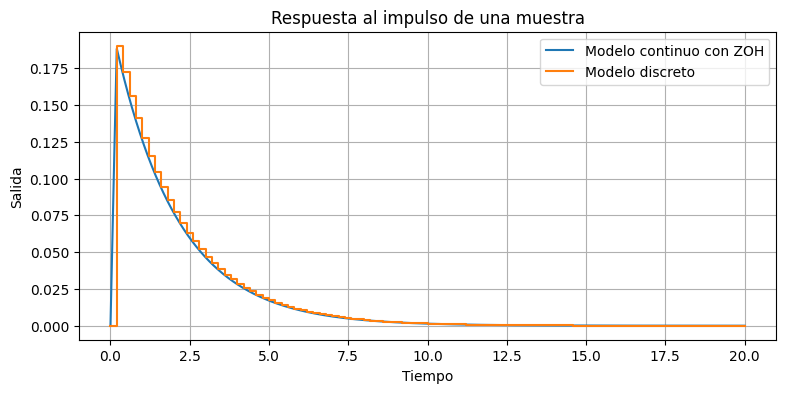

In [ ]:
t_cont = np.linspace(0.0, tfin, 5001)
u_cont = (t_cont < Td).astype(float)

tout, y_cont, _ = signal.lsim(G_cont, U=u_cont, T=t_cont)

plt.figure(figsize=(9, 4))
plt.plot(tout, y_cont, label="Modelo continuo con ZOH")
plt.step(t_disc, ypulse, where="post", label="Modelo discreto")
plt.xlabel("Tiempo")
plt.ylabel("Salida")
plt.title("Respuesta al impulso de una muestra")
plt.grid(True)
plt.legend()
plt.show()


### Pregunta sobre la comparación continuo–discreto

> **Pregunta 14.** En la figura, las muestras del modelo discreto coinciden con el continuo. ¿Significa eso que ambos modelos son iguales para todo instante?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No. La discretización ZOH garantiza la equivalencia en los **instantes de muestreo** bajo la hipótesis de que la entrada permanece constante entre muestras.

El sistema continuo sigue evolucionando entre muestras, mientras que el controlador MAC trabaja únicamente con la información discreta disponible en los instantes $kT_d$.

</details>


## 5. Obtención del modelo FIR y elección de $N_t$

Para analizar el efecto del truncamiento se propone

\begin{align*}
h_i = y_{\mathrm{imp}}(i),\qquad i=1,\ldots,N_t,
\end{align*}

omitiendo la primera muestra, que es cero.

En la siguiente celda se cuantifica explícitamente el error de truncamiento para los siguientes valores $N_t = 10, 15, 30, 60$.

Definiremos como indicador

\begin{align*}
\varepsilon_{\mathrm{cola}}
=
\frac{\sum_{i>N_t}|h_i|}
     {\sum_{i\ge 1}|h_i|}.
\end{align*}

No es la única métrica posible, pero permite visualizar cuánto peso de la respuesta impulsional se está descartando.

In [ ]:
h_full = ypulse[1:]  # se elimina y(0)=0

def tail_fraction(h_full, Nt):
    num = np.sum(np.abs(h_full[Nt:]))
    den = np.sum(np.abs(h_full))
    return num / den

for Nt_test in [10, 15, 30, 60]:
    print(
        f"Nt={Nt_test:2d} -> fracción de cola omitida = "
        f"{100*tail_fraction(h_full, Nt_test):6.3f} %"
    )

# Criterio orientativo: primer hi inferior al 1 % de h1
relative = np.abs(h_full) / abs(h_full[0])
indices = np.where(relative < 0.01)[0]
Nt_1pct = int(indices[0] + 1) if len(indices) else len(h_full)

print()
print(f"Primer índice con |hi| < 1 % de |h1|: Nt ≈ {Nt_1pct}")

Nt=10 -> fracción de cola omitida = 36.785 %
Nt=15 -> fracción de cola omitida = 22.309 %
Nt=30 -> fracción de cola omitida =  4.974 %
Nt=60 -> fracción de cola omitida =  0.243 %

Primer índice con |hi| < 1 % de |h1|: Nt ≈ 48



### Preguntas para dinamizar — truncamiento del modelo FIR

MAC no utiliza una respuesta impulsional infinita. Se aproxima mediante

\begin{align*}
y(k)\simeq\sum_{i=1}^{N_t} h_i\,u(k-i).
\end{align*}

> **Pregunta 15.** ¿Por qué necesitamos truncar la respuesta impulsional?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque una implementación real necesita un modelo con memoria finita. No podemos almacenar ni utilizar un número infinito de coeficientes.

En una planta estable los $h_i$ tienden a cero, de modo que a partir de cierto índice su contribución puede considerarse despreciable.

</details>

> **Pregunta 16.** ¿Qué compromiso introduce la elección de $N_t$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Un $N_t$ pequeño reduce memoria y cálculo, pero elimina parte de la dinámica y aumenta el error de predicción.

Un $N_t$ grande reduce el error de truncamiento, pero aumenta el tamaño de los buffers y de algunas operaciones del predictor. Cuando los nuevos coeficientes ya son prácticamente nulos, seguir aumentando $N_t$ aporta muy poca mejora.

</details>

> **Pregunta 17.** Entre otras opciones, se proponen $N_t=15$ y $N_t=60$. ¿Cuál elegiríais antes de mirar la gráfica?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No conviene elegirlo únicamente por el valor numérico. Primero deberíamos cuantificar cuánta respuesta impulsional queda fuera de cada truncamiento.

La siguiente celda calcula precisamente la fracción de cola omitida. La decisión correcta debe basarse en el error que estamos dispuestos a aceptar y en la dinámica que queremos conservar.

</details>


### Comparación del modelo FIR truncado

La función *fir_impulse_respose* es especialmente sencilla: ante un impulso, el modelo FIR produce directamente la secuencia $h_i$ hasta $N_t$ y cero después.

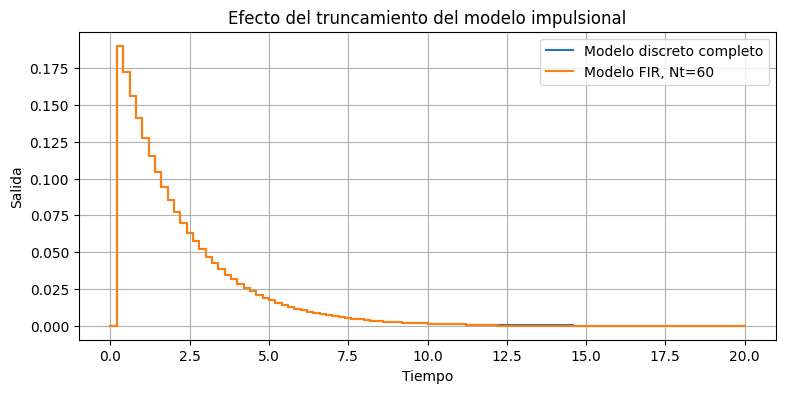

Fracción de cola omitida para Nt=60: 0.2433 %


In [ ]:
def fir_impulse_response(hi, total_samples):
    y = np.zeros(total_samples + 1)
    n = min(len(hi), total_samples)
    y[1:n+1] = hi[:n]
    return y


Nt = 60
hi = h_full[:Nt]

y_fir = fir_impulse_response(hi, n_imp)

plt.figure(figsize=(9, 4))
plt.step(t_disc, ypulse, where="post", label="Modelo discreto completo")
plt.step(t_disc, y_fir, where="post", label=f"Modelo FIR, Nt={Nt}")
plt.xlabel("Tiempo")
plt.ylabel("Salida")
plt.title("Efecto del truncamiento del modelo impulsional")
plt.grid(True)
plt.legend()
plt.show()

print(f"Fracción de cola omitida para Nt={Nt}: {100*tail_fraction(h_full, Nt):.4f} %")

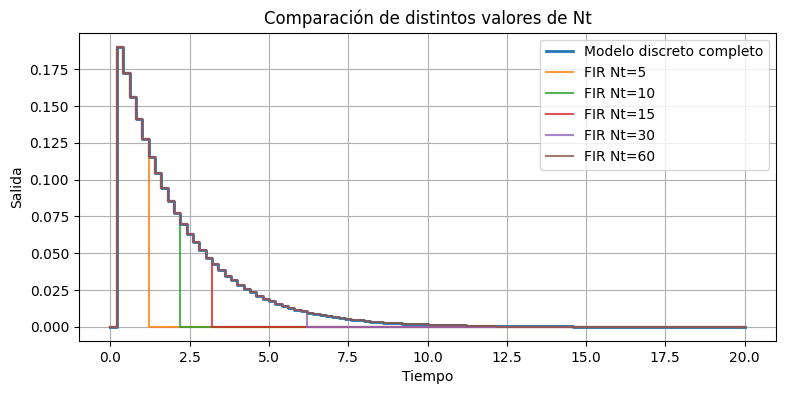

Error de cola:
Nt= 5 ->  60.6513 % omitido
Nt=10 ->  36.7851 % omitido
Nt=15 ->  22.3095 % omitido
Nt=30 ->   4.9744 % omitido
Nt=60 ->   0.2433 % omitido


In [ ]:
# Experimento en directo: comparar visualmente varios truncamientos
# Antes de ejecutar: ¿a partir de qué Nt creéis que las curvas serán casi indistinguibles?

Nt_values = [5, 10, 15, 30, 60]

plt.figure(figsize=(9, 4))
plt.step(t_disc, ypulse, where="post", linewidth=2, label="Modelo discreto completo")

for Nt_test in Nt_values:
    h_test = h_full[:Nt_test]
    y_test = fir_impulse_response(h_test, n_imp)
    plt.step(
        t_disc, y_test, where="post",
        label=f"FIR Nt={Nt_test}", alpha=0.8
    )

plt.xlabel("Tiempo")
plt.ylabel("Salida")
plt.title("Comparación de distintos valores de Nt")
plt.grid(True)
plt.legend()
plt.show()

print("Error de cola:")
for Nt_test in Nt_values:
    print(
        f"Nt={Nt_test:2d} -> "
        f"{100*tail_fraction(h_full, Nt_test):8.4f} % omitido"
    )



> **Pregunta 18.** ¿Qué sucede si escogemos $N_t$ demasiado pequeño aunque el controlador esté perfectamente optimizado?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

El optimizador trabaja con un modelo incompleto. Puede resolver exactamente el problema matemático planteado y, aun así, generar una acción inadecuada porque la predicción no contiene toda la dinámica relevante de la planta.

Es importante distinguir entre:

- **error de optimización:** no resolver correctamente el problema;
- **error de modelo:** resolver correctamente un problema construido con una representación insuficiente de la planta.

En este caso el problema sería de modelo.

</details>

> **Pregunta 19.** ¿Por qué el modelo impulsional FIR utilizado por MAC resulta problemático para una planta inestable?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque en una planta inestable la respuesta impulsional no decae hacia cero. Por tanto, no existe un punto natural a partir del cual podamos truncar la secuencia suponiendo que los coeficientes restantes son despreciables.

Esta limitación está asociada al uso directo de un modelo de convolución FIR.

</details>

> **Pregunta 20.** Si reducimos $T_d$ a la mitad manteniendo exactamente el mismo $N_t$, ¿estamos representando la misma duración física de la memoria?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No. La duración física cubierta por el FIR es aproximadamente

\begin{align*}
T_{\mathrm{mem}}=N_t T_d.
\end{align*}

Si reducimos $T_d$ a la mitad y mantenemos $N_t$, también reducimos a la mitad la ventana temporal representada por el modelo.

Por eso $T_d$ y $N_t$ deben considerarse conjuntamente.

</details>


## 6. Predictor vectorial MAC

A lo largo de un horizonte de predicción $h$,

\begin{align*}
\hat{\mathbf y}=G\mathbf u^+ + \mathbf f,
\end{align*}

donde

- $G\mathbf u^+$ es la **respuesta forzada**, debida a las futuras acciones de control;
- $\mathbf f$ es la **respuesta libre**, debida a la situación actual y a las acciones de control pasadas.

La respuesta libre se plantea como

\begin{align*}
\boxed{\mathbf f=F\mathbf u^-+\mathbf 1\,y(k)}.
\end{align*}

El vector de acciones pasadas se define como

\begin{align*}
\mathbf u^-=
\begin{bmatrix}
u(k-1)&u(k-2)&\cdots&u(k-N_t)
\end{bmatrix}^{T}.
\end{align*}

La matriz $G$ es triangular inferior:

\begin{align*}
G=
\begin{bmatrix}
h_1 & 0 & \cdots & 0\\
h_2 & h_1 & \cdots & 0\\
\vdots & \vdots & \ddots & \vdots\\
h_h & h_{h-1} & \cdots & h_1
\end{bmatrix}.
\end{align*}

Para $F$, a partir de la expresión del predictor del material,

\begin{align*}
F_{k,i}=h_{i+k}-h_i,
\end{align*}

considerando $h_j=0$ para $j>N_t$.

In [ ]:
def create_mac_matrices(hi, horizon):
    """Construye las matrices G y F del predictor MAC SISO."""
    hi = np.asarray(hi, dtype=float).reshape(-1)
    Nt = len(hi)

    G = np.zeros((horizon, horizon))
    F = np.zeros((horizon, Nt))

    # G: respuesta forzada
    for k in range(1, horizon + 1):
        for j in range(1, horizon + 1):
            if j <= k:
                h_index = k - j + 1  # índice 1-based del coeficiente h
                if h_index <= Nt:
                    G[k - 1, j - 1] = hi[h_index - 1]

    # F: contribución de las entradas pasadas
    for k in range(1, horizon + 1):
        for i in range(1, Nt + 1):
            h_i = hi[i - 1]
            h_i_plus_k = hi[i + k - 1] if (i + k) <= Nt else 0.0
            F[k - 1, i - 1] = h_i_plus_k - h_i

    return G, F


horizon = 10
assert horizon < Nt, "En esta práctica se recomienda mantener h < Nt."

G, F = create_mac_matrices(hi, horizon)

print("Dimensión de G:", G.shape)
print("Dimensión de F:", F.shape)
print()
print("G =")
print(G)

Dimensión de G: (10, 10)
Dimensión de F: (10, 60)

G =
[[0.19033 0.      0.      0.      0.      0.      0.      0.      0.
  0.     ]
 [0.17221 0.19033 0.      0.      0.      0.      0.      0.      0.
  0.     ]
 [0.15583 0.17221 0.19033 0.      0.      0.      0.      0.      0.
  0.     ]
 [0.141   0.15583 0.17221 0.19033 0.      0.      0.      0.      0.
  0.     ]
 [0.12758 0.141   0.15583 0.17221 0.19033 0.      0.      0.      0.
  0.     ]
 [0.11544 0.12758 0.141   0.15583 0.17221 0.19033 0.      0.      0.
  0.     ]
 [0.10445 0.11544 0.12758 0.141   0.15583 0.17221 0.19033 0.      0.
  0.     ]
 [0.09451 0.10445 0.11544 0.12758 0.141   0.15583 0.17221 0.19033 0.
  0.     ]
 [0.08552 0.09451 0.10445 0.11544 0.12758 0.141   0.15583 0.17221 0.19033
  0.     ]
 [0.07738 0.08552 0.09451 0.10445 0.11544 0.12758 0.141   0.15583 0.17221
  0.19033]]



### Preguntas para dinamizar — estructura del predictor MAC

> **Pregunta 21.** ¿Por qué la matriz $G$ es triangular inferior?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque una acción de control futura solo puede afectar a la salida en ese instante o en instantes posteriores.

Por ejemplo, $u(k)$ puede influir sobre $\hat y(k+1|k)$, $\hat y(k+2|k)$, etc. En cambio, $u(k+2)$ no puede influir sobre $\hat y(k+1|k)$.

Por causalidad aparecen ceros por encima de la diagonal.

</details>

> **Pregunta 22.** ¿Qué representa físicamente la primera columna de $G$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

La primera columna contiene el efecto futuro de la acción que vamos a aplicar ahora, $u(k)$:

\begin{align*}
\begin{bmatrix}
h_1 & h_2 & \cdots & h_h
\end{bmatrix}^{T}.
\end{align*}

Es decir, describe cómo una única decisión actual se propaga a lo largo de todo el horizonte de predicción.

</details>

> **Pregunta 23.** ¿Y qué representa la última columna de $G$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Representa el efecto de la última acción incluida en el horizonte, $u(k+h-1)$.

Como esa acción se produciría al final del horizonte, solo puede afectar a la última predicción. Por eso la última columna tiene ceros salvo, en este caso, el término $h_1$ de la última fila.

</details>

> **Pregunta 24.** Si $h=10$, ¿cuántas acciones futuras está optimizando MAC en esta formulación?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Diez acciones:

\begin{align*}
\mathbf u^+
=
\begin{bmatrix}
u(k)&u(k+1)&\cdots&u(k+9)
\end{bmatrix}^{T}.
\end{align*}

En esta práctica el horizonte de control coincide con el horizonte de predicción.

</details>


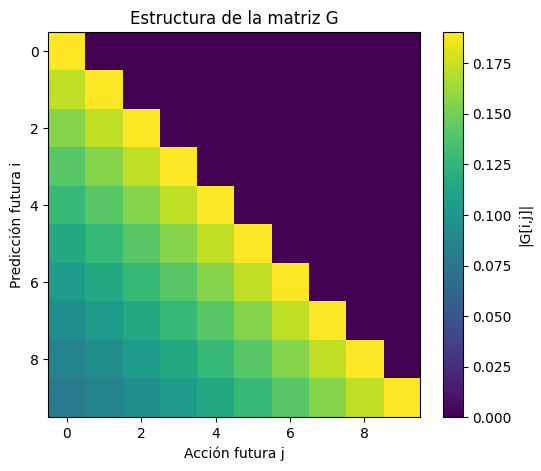

Primera columna de G:
[0.19033 0.17221 0.15583 0.141   0.12758 0.11544 0.10445 0.09451 0.08552
 0.07738]

Última columna de G:
[0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.19033]


In [ ]:
# Experimento en directo: visualizar la estructura causal de G
plt.figure(figsize=(6, 5))
plt.imshow(np.abs(G), aspect="auto")
plt.colorbar(label="|G[i,j]|")
plt.xlabel("Acción futura j")
plt.ylabel("Predicción futura i")
plt.title("Estructura de la matriz G")
plt.show()

print("Primera columna de G:")
print(G[:, 0])

print("\nÚltima columna de G:")
print(G[:, -1])



### Respuesta libre frente a respuesta forzada

> **Pregunta 25.** Si fijásemos todas las acciones futuras a cero, $\mathbf u^+=0$, ¿qué predicción obtendríamos?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Quedaría únicamente la respuesta libre:

\begin{align*}
\hat{\mathbf y}=\mathbf f.
\end{align*}

Por tanto, $\mathbf f$ es la evolución que el modelo espera debido a la situación actual y a las acciones pasadas si no añadimos nuevas acciones futuras.

</details>

> **Pregunta 26.** ¿Por qué necesitamos guardar un buffer de entradas pasadas $\mathbf u^-$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque la planta tiene memoria. Una entrada aplicada hace varias muestras continúa afectando a la salida actual y futura.

El vector

\begin{align*}
\mathbf u^-=
\begin{bmatrix}
u(k-1)&u(k-2)&\cdots&u(k-N_t)
\end{bmatrix}^{T}
\end{align*}

permite reconstruir ese efecto mediante la matriz $F$.

</details>

> **Pregunta 27.** Supongamos que $y(k)$ coincide exactamente con la referencia. ¿Significa eso necesariamente que $\mathbf f$ también coincidirá con la referencia a lo largo de todo el horizonte?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No. Que el error actual sea cero no implica que la evolución futura libre vaya a permanecer en la referencia.

Las acciones pasadas almacenadas en $\mathbf u^-$ pueden hacer que la salida continúe evolucionando. Esta es precisamente una diferencia clave entre reaccionar al error presente y predecir el futuro.

</details>


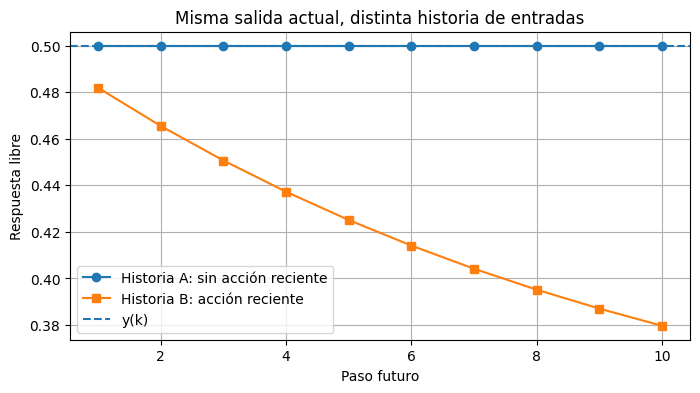

In [ ]:
# Experimento conceptual: misma salida actual, distinta historia de entradas
# Se comparan dos respuestas libres con el mismo y(k), pero buffers distintos.

yk_demo = 0.5

u_past_A = np.zeros(Nt)
u_past_B = np.zeros(Nt)
u_past_B[0] = 1.0  # hubo una acción reciente

f_A = F @ u_past_A + np.ones(horizon) * yk_demo
f_B = F @ u_past_B + np.ones(horizon) * yk_demo

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, horizon + 1), f_A, "o-", label="Historia A: sin acción reciente")
plt.plot(np.arange(1, horizon + 1), f_B, "s-", label="Historia B: acción reciente")
plt.axhline(yk_demo, linestyle="--", label="y(k)")
plt.xlabel("Paso futuro")
plt.ylabel("Respuesta libre")
plt.title("Misma salida actual, distinta historia de entradas")
plt.grid(True)
plt.legend()
plt.show()


## 7. Función objetivo y ley de control

El MAC sin restricciones minimiza

\begin{align*}
J=
(\hat{\mathbf y}-\mathbf w)^T(\hat{\mathbf y}-\mathbf w)
+
\lambda\,{\mathbf u^+}^T\mathbf u^+.
\end{align*}

Sustituyendo el predictor,

\begin{align*}
\hat{\mathbf y}=G\mathbf u^+ + \mathbf f,
\end{align*}

la solución analítica es

\begin{align*}
\mathbf u^*
=
(G^T G+\lambda I)^{-1}G^T(\mathbf w-\mathbf f).
\end{align*}

Como se aplica únicamente la primera acción del vector óptimo,

\begin{align*}
\boxed{
u(k)=K_1(\mathbf w-\mathbf f)
}
\end{align*}

donde $K_1$ es la primera fila de

\begin{align*}
K=(G^TG+\lambda I)^{-1}G^T.
\end{align*}

El valor de partida es

\begin{align*}
h=10,\qquad \lambda=0.1.
\end{align*}

In [ ]:
lam = 0.1

# Se usa solve() en lugar de calcular explícitamente una inversa.
K = np.linalg.solve(G.T @ G + lam * np.eye(horizon), G.T)
K1 = K[0, :]

print("K1 =")
print(K1)

K1 =
[1.12015 0.59653 0.31769 0.1692  0.09015 0.04809 0.02577 0.01402 0.00803
 0.00533]



### Preguntas para dinamizar — función objetivo

La función de coste contiene dos objetivos que compiten:

\begin{align*}
J=
\underbrace{(\hat{\mathbf y}-\mathbf w)^T(\hat{\mathbf y}-\mathbf w)}_{\text{seguimiento}}
+
\underbrace{\lambda\,{\mathbf u^+}^T\mathbf u^+}_{\text{esfuerzo de control}}.
\end{align*}

> **Pregunta 28.** Si $\lambda=0$, ¿qué único objetivo queda en la función de coste?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Solo se penaliza el error de seguimiento. El controlador intentará hacer coincidir la predicción con la referencia sin considerar explícitamente cuánto esfuerzo requiere la acción de control.

Eso puede generar acciones muy grandes y también empeorar el condicionamiento numérico del problema.

</details>

> **Pregunta 29.** ¿Qué sucede cualitativamente al aumentar $\lambda$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Se penaliza más la magnitud de las acciones futuras. El controlador se vuelve menos agresivo:

- disminuye normalmente la amplitud de $u(k)$;
- el seguimiento tiende a ser más lento;
- puede aumentar el error estacionario en esta formulación MAC, porque mantener una acción distinta de cero también tiene coste.

</details>

> **Pregunta 30.** ¿Es $\lambda$ únicamente un parámetro de “suavizado”?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No exactamente. En este MAC se penaliza directamente $u$, no $\Delta u$. Por tanto, $\lambda$ penaliza la **magnitud** de la acción de control.

Además, el término $\lambda I$ mejora el condicionamiento de

\begin{align*}
G^TG+\lambda I,
\end{align*}

por lo que también actúa como regularización numérica.

</details>

> **Pregunta 31.** ¿Por qué en el código se usa `np.linalg.solve(...)` en lugar de calcular explícitamente la inversa?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque para resolver

\begin{align*}
AX=B
\end{align*}

es numéricamente preferible resolver directamente el sistema lineal que calcular $A^{-1}$ y multiplicar después.

La expresión matemática puede escribirse con una inversa para derivar la ley de control, pero en código conviene evitar `inv()` cuando no es necesario.

</details>


In [ ]:
# Experimento en directo: cómo cambia la ganancia K1 con lambda
# Antes de ejecutar: ¿esperamos que ||K1|| aumente o disminuya?

lambda_demo = [0.0, 0.001, 0.01, 0.1, 1.0, 10.0]

for lam_test in lambda_demo:
    M = G.T @ G + lam_test * np.eye(horizon)

    try:
        K_test = np.linalg.solve(M, G.T)
        K1_test = K_test[0, :]
        cond = np.linalg.cond(M)

        print(
            f"lambda={lam_test:7.3g}  "
            f"||K1||2={np.linalg.norm(K1_test):9.4f}  "
            f"cond={cond:12.4e}"
        )
    except np.linalg.LinAlgError:
        print(f"lambda={lam_test:7.3g}  -> matriz singular")


lambda=      0  ||K1||2=   5.2542  cond=  8.2084e+01
lambda=  0.001  ||K1||2=   5.0072  cond=  7.4850e+01
lambda=   0.01  ||K1||2=   3.6543  cond=  4.1960e+01
lambda=    0.1  ||K1||2=   1.3235  cond=  8.5107e+00
lambda=      1  ||K1||2=   0.2835  cond=  1.8194e+00
lambda=     10  ||K1||2=   0.0393  cond=  1.0827e+00



### Horizonte deslizante

> **Pregunta 32.** Si calculamos un vector completo $\mathbf u^*$ de $h$ acciones óptimas, ¿por qué aplicamos solamente la primera?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque en el siguiente instante tendremos una nueva medida de la planta. Entonces volvemos a calcular la predicción y resolvemos de nuevo el problema con información actualizada.

Esta realimentación por horizonte deslizante permite corregir continuamente:

- perturbaciones;
- errores de modelo;
- diferencias entre la trayectoria predicha y la real.

Si aplicásemos toda la secuencia calculada sin volver a optimizar, estaríamos utilizando esencialmente una estrategia en lazo abierto durante todo el horizonte.

</details>

> **Pregunta 33.** ¿Qué creéis que ocurriría si el modelo fuese perfecto y no existiesen perturbaciones? ¿Seguiría teniendo sentido recalcular?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

En ese caso ideal, la secuencia futura calculada podría coincidir con la evolución posterior esperada. Aun así, la filosofía MPC consiste en recalcular porque en una implementación real siempre pueden aparecer perturbaciones, errores de medida o discrepancias de modelo.

El valor práctico del horizonte deslizante aparece precisamente cuando la realidad se desvía de la predicción.

</details>


## 8. Simulación MAC

El bucle implementa explícitamente el horizonte deslizante:

1. medir $y(k)$;
2. calcular la respuesta libre $\mathbf f$;
3. construir la referencia futura $\mathbf w$;
4. calcular $u(k)$;
5. aplicar solamente esa primera acción a la planta;
6. desplazar los buffers;
7. repetir en $k+1$.

En la siguiente celda se implementan las funciones que se emplearán para la simulación MAC.

In [ ]:
def future_reference(ref, k, horizon):
    """Referencia real r(k+1)...r(k+h), manteniendo el último valor al final."""
    w = np.empty(horizon)
    for j in range(1, horizon + 1):
        idx = min(k + j, len(ref) - 1)
        w[j - 1] = ref[idx]
    return w


def filtered_reference(ref, k, horizon, yk, alpha):
    """Filtro de primer orden: w(k+j)=alpha*w(k+j-1)+(1-alpha)*r(k+j)."""
    w = np.empty(horizon)
    previous = yk

    for j in range(1, horizon + 1):
        idx = min(k + j, len(ref) - 1)
        previous = alpha * previous + (1.0 - alpha) * ref[idx]
        w[j - 1] = previous

    return w


def simulate_mac(Ad, Bd, Cd, Dd, hi, horizon, lam, ref, alpha=None):
    """Simulación completa de un controlador MAC SISO sin restricciones."""
    G, F = create_mac_matrices(hi, horizon)
    K = np.linalg.solve(G.T @ G + lam * np.eye(horizon), G.T)
    K1 = K[0, :]

    Nt = len(hi)
    N = len(ref) - 1

    y = np.zeros(N + 1)
    u = np.zeros(N)
    x = 0.0

    # [u(k-1), u(k-2), ..., u(k-Nt)]
    u_past = np.zeros(Nt)

    for k in range(N):
        y[k] = Cd * x

        # Respuesta libre
        f = F @ u_past + np.ones(horizon) * y[k]

        # Referencia futura
        if alpha is None:
            w = future_reference(ref, k, horizon)
        else:
            w = filtered_reference(ref, k, horizon, y[k], alpha)

        # Primera acción de la secuencia óptima
        uk = float(K1 @ (w - f))
        u[k] = uk

        # Planta discreta
        x = Ad * x + Bd * uk

        # Actualización del buffer de entradas pasadas
        u_past[1:] = u_past[:-1]
        u_past[0] = uk

    y[N] = Cd * x

    return y, u


### Preguntas para dinamizar — una iteración del horizonte deslizante

> **Pregunta 34.** En el bucle de simulación, ¿qué información utiliza el controlador en el instante $k$ y qué parte pertenece al futuro?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

En el instante $k$ se conoce:

- la salida actual $y(k)$;
- el historial de acciones pasadas $\mathbf u^-$;
- el modelo impulsional;
- la referencia futura $\mathbf w$, si está disponible.

Lo que no se conoce es la salida futura real. Esa salida se **predice** mediante

\begin{align*}
\hat{\mathbf y}=G\mathbf u^+ + \mathbf f.
\end{align*}

Las acciones futuras $\mathbf u^+$ son variables de decisión del problema de optimización.

</details>

> **Pregunta 35.** ¿Por qué es importante actualizar el buffer `u_past` después de aplicar $u(k)$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque en el siguiente instante $u(k)$ ya será una acción pasada y seguirá influyendo sobre la planta.

El desplazamiento

\begin{align*}
[u(k-1),u(k-2),\ldots]
\rightarrow
[u(k),u(k-1),\ldots]
\end{align*}

mantiene correctamente la memoria necesaria para calcular la respuesta libre.

</details>

> **Pregunta 36.** ¿Qué diferencia habría entre calcular una única secuencia óptima al principio y ejecutar este bucle muestra a muestra?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

El bucle vuelve a medir y recalcular en cada muestra. Esa es la implementación del **horizonte deslizante**.

Si calculásemos una secuencia una sola vez y la aplicásemos completa, perderíamos la capacidad de corregir la trayectoria cuando aparezcan perturbaciones, errores de modelo o desviaciones respecto a la predicción.

</details>


## 9. Referencia de la práctica

Se propone la siguiente señal de referencia:

\begin{align*}
0 \rightarrow 0.5 \rightarrow -0.1 \rightarrow 0.1.
\end{align*}

Se genera un vector de $N$ elementos donde $N=1000$.

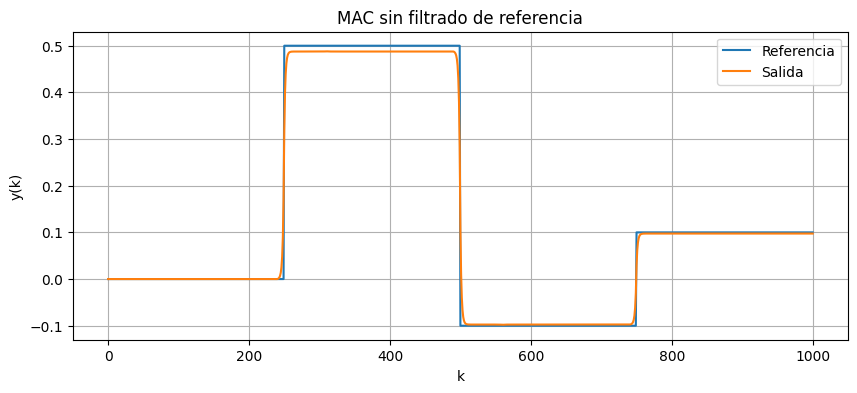

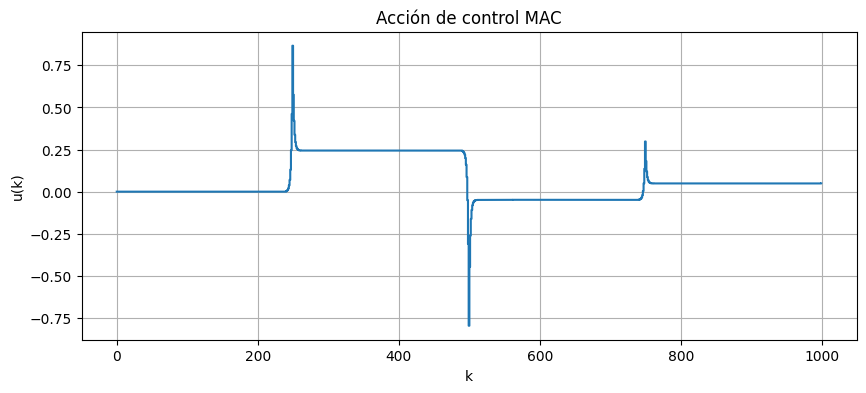

In [ ]:
N = 1000

ref = np.zeros(N + 1)
q = N // 4

ref[q:2*q] = 0.5
ref[2*q:3*q] = -0.1
ref[3*q:] = 0.1

y_mac, u_mac = simulate_mac(
    Ad, Bd, Cd, Dd,
    hi=hi,
    horizon=horizon,
    lam=lam,
    ref=ref,
    alpha=None
)

k_y = np.arange(N + 1)
k_u = np.arange(N)

plt.figure(figsize=(10, 4))
plt.plot(k_y, ref, label="Referencia")
plt.plot(k_y, y_mac, label="Salida")
plt.xlabel("k")
plt.ylabel("y(k)")
plt.title("MAC sin filtrado de referencia")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.step(k_u, u_mac, where="post")
plt.xlabel("k")
plt.ylabel("u(k)")
plt.title("Acción de control MAC")
plt.grid(True)
plt.show()


### Referencia futura: capacidad de anticipación

La función `future_reference()` construye

\begin{align*}
\mathbf w=
\begin{bmatrix}
r(k+1)&r(k+2)&\cdots&r(k+h)
\end{bmatrix}^{T}.
\end{align*}

> **Pregunta 37.** Si sabemos que la referencia cambiará dentro de 5 muestras y $h=10$, ¿puede MAC empezar a actuar antes de que el cambio ocurra?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Sí. El cambio ya aparece dentro del vector de referencia futura $\mathbf w$, por lo que influye en la optimización actual.

Esta es una diferencia importante respecto a un controlador que solo utiliza el error presente: el MPC puede **anticipar** cambios conocidos de consigna.

</details>

> **Pregunta 38.** ¿Hasta cuántas muestras antes puede "ver" un cambio de referencia con $h=10$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Hasta 10 muestras hacia delante, porque ese es el horizonte de referencia que entra en el problema.

Eso no significa que siempre vaya a actuar exactamente 10 muestras antes: dependerá de la dinámica de la planta, de $G$, de $\lambda$ y del peso efectivo de cada punto futuro en la ley de control.

</details>

> **Pregunta 39.** ¿Qué ocurriría si en lugar de usar la referencia futura repitiésemos simplemente el valor actual $r(k)$ a lo largo de todo el horizonte?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

El controlador perdería la capacidad de anticipar cambios de consigna. Solo reaccionaría cuando el nuevo valor ya fuese el valor actual de referencia.

Seguiría siendo un controlador predictivo respecto a la planta, pero no aprovecharía información futura de la referencia.

</details>


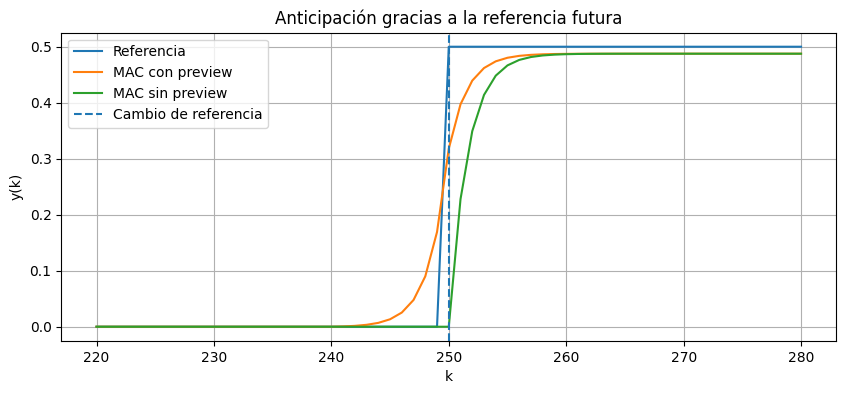

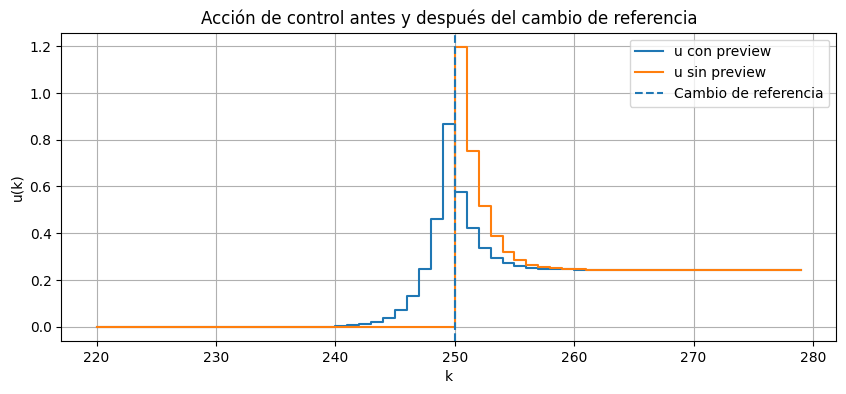

In [ ]:
# Experimento en directo: con y sin conocimiento de la referencia futura

def held_reference(ref, k, horizon):
    """Repite el valor actual r(k) a lo largo de todo el horizonte."""
    return np.full(horizon, ref[min(k, len(ref)-1)])


def simulate_mac_no_preview(Ad, Bd, Cd, Dd, hi, horizon, lam, ref):
    """MAC idéntico, pero sin preview: usa r(k) constante en el horizonte."""
    G, F = create_mac_matrices(hi, horizon)
    K = np.linalg.solve(G.T @ G + lam * np.eye(horizon), G.T)
    K1 = K[0, :]

    Nt = len(hi)
    N = len(ref) - 1

    y = np.zeros(N + 1)
    u = np.zeros(N)
    x = 0.0
    u_past = np.zeros(Nt)

    for k in range(N):
        y[k] = Cd * x
        f = F @ u_past + np.ones(horizon) * y[k]
        w = held_reference(ref, k, horizon)

        uk = float(K1 @ (w - f))
        u[k] = uk

        x = Ad * x + Bd * uk
        u_past[1:] = u_past[:-1]
        u_past[0] = uk

    y[N] = Cd * x
    return y, u


y_preview, u_preview = simulate_mac(
    Ad, Bd, Cd, Dd, hi, horizon, lam, ref, alpha=None
)

y_no_preview, u_no_preview = simulate_mac_no_preview(
    Ad, Bd, Cd, Dd, hi, horizon, lam, ref
)

# Ampliamos una zona alrededor del primer cambio de referencia
k0 = q
window = 30
sl_y = slice(k0-window, k0+window+1)
sl_u = slice(k0-window, k0+window)

plt.figure(figsize=(10, 4))
plt.plot(k_y[sl_y], ref[sl_y], label="Referencia")
plt.plot(k_y[sl_y], y_preview[sl_y], label="MAC con preview")
plt.plot(k_y[sl_y], y_no_preview[sl_y], label="MAC sin preview")
plt.axvline(k0, linestyle="--", label="Cambio de referencia")
plt.xlabel("k")
plt.ylabel("y(k)")
plt.title("Anticipación gracias a la referencia futura")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.step(k_u[sl_u], u_preview[sl_u], where="post", label="u con preview")
plt.step(k_u[sl_u], u_no_preview[sl_u], where="post", label="u sin preview")
plt.axvline(k0, linestyle="--", label="Cambio de referencia")
plt.xlabel("k")
plt.ylabel("u(k)")
plt.title("Acción de control antes y después del cambio de referencia")
plt.grid(True)
plt.legend()
plt.show()



> **Pregunta 40.** En la comparación anterior, ¿por qué puede aparecer movimiento en $u(k)$ antes del instante exacto del cambio de referencia?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque con `future_reference()` el cambio entra en $\mathbf w$ antes de producirse. El optimizador ve que una acción aplicada ahora tendrá efecto sobre las salidas futuras y puede comenzar a preparar la planta.

Con `held_reference()` esa información no está disponible y el controlador espera hasta que la referencia actual cambia.

</details>


## 10. Análisis del error estacionario

Observar el error estacionario del MAC con

\begin{align*}
\lambda=0.1,\qquad h=10.
\end{align*}

Se calculan de forma orientativa los errores medios durante las últimas 50 muestras de cada tramo constante de referencia.

In [ ]:
def mean_error_over_last_samples(ref, y, start, end, n_last=50):
    a = max(start, end - n_last)
    return float(np.mean(ref[a:end] - y[a:end]))

segments = [
    (q, 2*q, 0.5),
    (2*q, 3*q, -0.1),
    (3*q, N, 0.1),
]

for start, end, r_value in segments:
    e_ss = mean_error_over_last_samples(ref, y_mac, start, end)
    print(f"Referencia {r_value:+.3f}: error medio final ≈ {e_ss:+.6f}")

Referencia +0.500: error medio final ≈ +0.021039
Referencia -0.100: error medio final ≈ -0.005353
Referencia +0.100: error medio final ≈ +0.002489



### Preguntas para dinamizar — error estacionario del MAC

> **Pregunta 41.** El modelo de la planta es exacto y no hemos añadido perturbaciones. ¿Por qué puede aparecer aun así error estacionario?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque el criterio de optimización no busca únicamente eliminar el error. También penaliza mantener una acción de control distinta de cero:

\begin{align*}
J=
(\hat{\mathbf y}-\mathbf w)^T(\hat{\mathbf y}-\mathbf w)
+
\lambda\,{\mathbf u^+}^T\mathbf u^+.
\end{align*}

Para mantener una referencia no nula, esta planta necesita una entrada estacionaria no nula. El optimizador encuentra un compromiso entre reducir el error y reducir la magnitud de $u$.

Por eso puede aceptar cierto offset aun con modelo perfecto.

</details>

> **Pregunta 42.** Si hacemos $\lambda$ cada vez más pequeño, ¿qué esperáis que suceda con el error estacionario?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

En general disminuirá, porque mantener una acción de control dejará de estar tan penalizado.

El precio será una acción más agresiva y potencialmente peor condicionamiento numérico cuando $\lambda$ se aproxima a cero.

</details>

> **Pregunta 43.** ¿Por qué este comportamiento será diferente en DMC, donde normalmente se penaliza $\Delta u$ en lugar de $u$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque una entrada constante distinta de cero cumple

\begin{align*}
\Delta u=0
\end{align*}

en régimen estacionario.

Por tanto, una penalización sobre $\Delta u$ no castiga directamente mantener el valor de entrada necesario para sostener una referencia constante. Esta diferencia será importante al comparar MAC y DMC.

</details>

> **Pregunta 44.** Si $\lambda$ fuese muy grande, ¿a qué solución tendería intuitivamente el controlador?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Tendería a reducir mucho la acción de control, porque el segundo término dominaría la función objetivo.

En el límite, el controlador preferiría utilizar una entrada muy pequeña aunque eso implique un error de seguimiento considerable.

</details>


In [ ]:
# Experimento en directo: cuantificar el compromiso error estacionario / esfuerzo

lambda_offset = [0.001, 0.01, 0.1, 1.0, 10.0]

print("Comparación sobre el tramo de referencia r=0.5")
print("lambda      error medio final      u medio final")
print("------------------------------------------------")

for lam_test in lambda_offset:
    y_test, u_test = simulate_mac(
        Ad, Bd, Cd, Dd,
        hi=hi,
        horizon=horizon,
        lam=lam_test,
        ref=ref
    )

    start, end = q, 2*q
    a = end - 50

    e_ss = np.mean(ref[a:end] - y_test[a:end])
    u_ss = np.mean(u_test[a:end])

    print(f"{lam_test:7.3g}      {e_ss:+16.8f}      {u_ss:+12.8f}")


Comparación sobre el tramo de referencia r=0.5
lambda      error medio final      u medio final
------------------------------------------------
  0.001           +0.00041064       +0.18822569
   0.01           +0.00335763       +0.19462035
    0.1           +0.02103888       +0.19937559
      1           +0.13868368       +0.15640881
     10           +0.40026468       +0.04490478



> **Pregunta 45.** Para una referencia $r=0.5$, ¿qué entrada estacionaria necesitaría idealmente la planta si el seguimiento fuese exacto?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

En régimen estacionario,

\begin{align*}
q=K_t h.
\end{align*}

Con $K_t=0.5$ y $h=0.5$,

\begin{align*}
q_{\mathrm{ss}}=0.5\cdot0.5=0.25.
\end{align*}

Esto ayuda a interpretar la tabla anterior: si el controlador reduce la entrada estacionaria por debajo de ese valor para ahorrar esfuerzo, necesariamente aparecerá un error de seguimiento.

</details>


## 11. Experimento A — Efecto de $\lambda$

Aumente la ponderación de la acción de control y analice simultáneamente:

- el seguimiento de referencia;
- la amplitud de $u(k)$;
- el error estacionario.

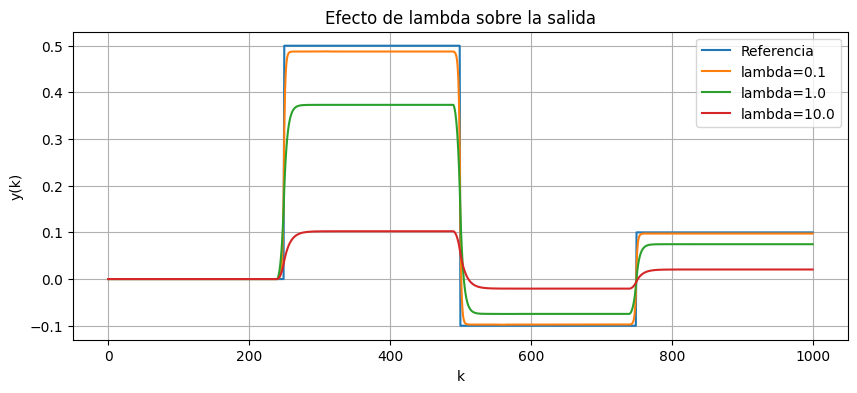

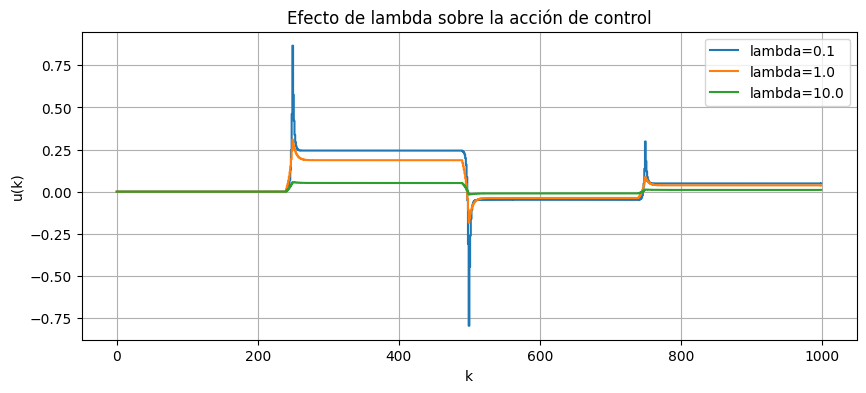

In [ ]:
lambda_values = [0.1, 1.0, 10.0]

plt.figure(figsize=(10, 4))
plt.plot(k_y, ref, label="Referencia")

for lam_test in lambda_values:
    y_test, _ = simulate_mac(
        Ad, Bd, Cd, Dd,
        hi=hi,
        horizon=horizon,
        lam=lam_test,
        ref=ref
    )
    plt.plot(k_y, y_test, label=f"lambda={lam_test}")

plt.xlabel("k")
plt.ylabel("y(k)")
plt.title("Efecto de lambda sobre la salida")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))

for lam_test in lambda_values:
    _, u_test = simulate_mac(
        Ad, Bd, Cd, Dd,
        hi=hi,
        horizon=horizon,
        lam=lam_test,
        ref=ref
    )
    plt.step(k_u, u_test, where="post", label=f"lambda={lam_test}")

plt.xlabel("k")
plt.ylabel("u(k)")
plt.title("Efecto de lambda sobre la acción de control")
plt.grid(True)
plt.legend()
plt.show()


### Preguntas para dinamizar — efecto de $\lambda$

> **Pregunta 46.** Antes de ejecutar las gráficas, ¿qué curva esperáis que presente la acción de control de mayor amplitud: $\lambda=0.1$, $1$ o $10$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

La de $\lambda=0.1$.

Al ser menor la penalización de

\begin{align*}
{\mathbf u^+}^T\mathbf u^+,
\end{align*}

el controlador está dispuesto a utilizar acciones mayores para reducir el error de seguimiento.

</details>

> **Pregunta 47.** ¿Esperáis que aumentar $\lambda$ modifique únicamente el transitorio o también el régimen estacionario?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

En esta formulación modifica ambos.

Como se penaliza directamente la magnitud de $u$, una entrada estacionaria distinta de cero tiene coste. Por eso, al aumentar $\lambda$, no solo se suaviza el transitorio: también puede aumentar el error estacionario.

</details>

> **Pregunta 48.** Si nuestro actuador tuviese un límite físico de amplitud, ¿sería suficiente aumentar $\lambda$ para garantizar que nunca se supera?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No.

Aumentar $\lambda$ puede reducir la magnitud de la acción de control, pero no impone una restricción dura del tipo

\begin{align*}
u_{\min}\leq u(k)\leq u_{\max}.
\end{align*}

Para garantizar límites físicos habría que formular un MPC con restricciones explícitas.

</details>

> **Pregunta 49.** ¿Existe entonces un “mejor” valor universal de $\lambda$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No. $\lambda$ expresa un compromiso entre seguimiento y esfuerzo de control. Su elección depende de la planta, del actuador y de los objetivos de operación.

En esta práctica interesa justificarlo observando simultáneamente:

- rapidez de seguimiento;
- error estacionario;
- amplitud de $u$.

</details>


In [ ]:
# Cuantificación para facilitar la discusión de lambda

print("lambda      max|u|       error_ss(r=0.5)")
print("------------------------------------------")

for lam_test in lambda_values:
    y_test, u_test = simulate_mac(
        Ad, Bd, Cd, Dd,
        hi=hi,
        horizon=horizon,
        lam=lam_test,
        ref=ref
    )

    e_ss = np.mean(ref[2*q-50:2*q] - y_test[2*q-50:2*q])
    print(
        f"{lam_test:7.3f}   "
        f"{np.max(np.abs(u_test)):10.5f}   "
        f"{e_ss:+16.8f}"
    )


lambda      max|u|       error_ss(r=0.5)
------------------------------------------
  0.100      0.86643        +0.02103888
  1.000      0.30924        +0.13868368
 10.000      0.05672        +0.40026468


## 12. Experimento B — Efecto del truncamiento $N_t$

El modelo MAC supone que los coeficientes despreciados son aproximadamente nulos.

Se compara ahora un modelo largo con modelos cada vez más truncados.

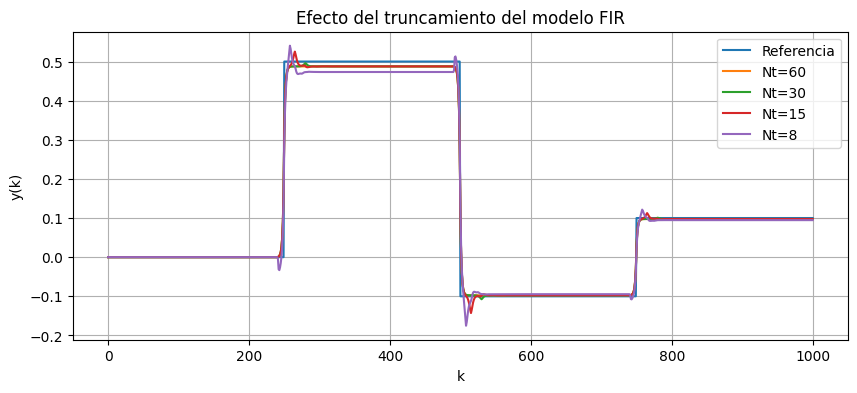

Nt=60: cola omitida ≈  0.243 %
Nt=30: cola omitida ≈  4.974 %
Nt=15: cola omitida ≈ 22.309 %
Nt= 8: cola omitida ≈ 44.930 %


In [ ]:
Nt_values = [60, 30, 15, 8]

plt.figure(figsize=(10, 4))
plt.plot(k_y, ref, label="Referencia")

for Nt_test in Nt_values:
    hi_test = h_full[:Nt_test]

    y_test, _ = simulate_mac(
        Ad, Bd, Cd, Dd,
        hi=hi_test,
        horizon=horizon,
        lam=lam,
        ref=ref
    )

    plt.plot(k_y, y_test, label=f"Nt={Nt_test}")

plt.xlabel("k")
plt.ylabel("y(k)")
plt.title("Efecto del truncamiento del modelo FIR")
plt.grid(True)
plt.legend()
plt.show()

for Nt_test in Nt_values:
    print(
        f"Nt={Nt_test:2d}: cola omitida ≈ "
        f"{100*tail_fraction(h_full, Nt_test):6.3f} %"
    )


### Preguntas para dinamizar — efecto de $N_t$ en lazo cerrado

> **Pregunta 50.** Si $N_t$ disminuye, ¿estamos cambiando la planta real o únicamente el modelo utilizado por el controlador?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Únicamente el modelo del controlador.

La planta simulada sigue siendo la misma. Lo que cambia es la cantidad de memoria dinámica que MAC utiliza para predecirla.

Por eso este experimento permite estudiar directamente el efecto del **error de modelado por truncamiento**.

</details>

> **Pregunta 51.** ¿Por qué puede haber diferencias apreciables en control aunque los últimos $h_i$ descartados sean pequeños individualmente?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque esos términos representan efectos pasados que se acumulan en la respuesta libre.

Un coeficiente pequeño puede parecer irrelevante de forma aislada, pero muchos términos omitidos pueden producir un error de predicción significativo, especialmente si las entradas pasadas no son pequeñas.

</details>

> **Pregunta 52.** ¿Esperáis que aumentar $N_t$ indefinidamente siga mejorando el control?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No.

Una vez que la cola omitida es despreciable, añadir más coeficientes prácticamente nulos no mejora de forma significativa la predicción, pero sí aumenta el tamaño del buffer y el coste de cálculo.

El objetivo es capturar la dinámica relevante, no maximizar $N_t$.

</details>

> **Pregunta 53.** Comparando $N_t=15$ y $N_t=60$, ¿qué criterio utilizaríais para decidir si merece la pena el modelo más largo?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Compararía la mejora real obtenida frente al aumento de complejidad.

En concreto:

- fracción de cola omitida;
- diferencias en la salida controlada;
- diferencias en $u(k)$;
- tamaño de las matrices y buffers.

Si las curvas son prácticamente indistinguibles, el valor menor puede ser preferible.

</details>


In [ ]:
# Cuantificación del efecto del truncamiento en lazo cerrado

print("Nt      cola omitida [%]     max|u|      error_ss(r=0.5)")
print("---------------------------------------------------------")

for Nt_test in Nt_values:
    hi_test = h_full[:Nt_test]

    y_test, u_test = simulate_mac(
        Ad, Bd, Cd, Dd,
        hi=hi_test,
        horizon=horizon,
        lam=lam,
        ref=ref
    )

    e_ss = np.mean(ref[2*q-50:2*q] - y_test[2*q-50:2*q])

    print(
        f"{Nt_test:2d}      "
        f"{100*tail_fraction(h_full, Nt_test):12.6f}      "
        f"{np.max(np.abs(u_test)):8.5f}      "
        f"{e_ss:+16.8f}"
    )


Nt      cola omitida [%]     max|u|      error_ss(r=0.5)
---------------------------------------------------------
60          0.243346       0.86643           +0.02103888
30          4.974393       0.86643           +0.02103888
15         22.309489       0.86645           +0.02103895
 8         44.930396       0.82639           +0.02976256


## 13. Experimento C — Filtrado de referencia

El material MAC propone suavizar la referencia mediante

\begin{align*}
w(k+j)=
\alpha\,w(k+j-1)
+
(1-\alpha)\,r(k+j),
\end{align*}

inicializando

\begin{align*}
w(k)=y(k).
\end{align*}

Se comparan

\begin{align*}
\alpha=0,\qquad 0.5,\qquad 0.9.
\end{align*}

En la siguiente celda se implementa directamente esta ecuación.

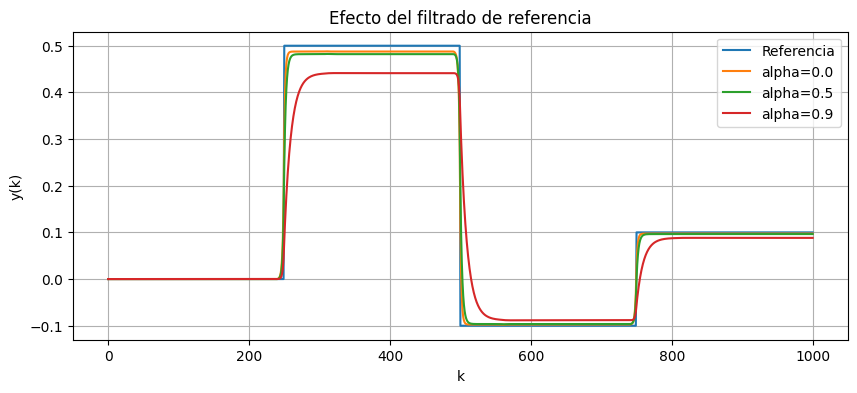

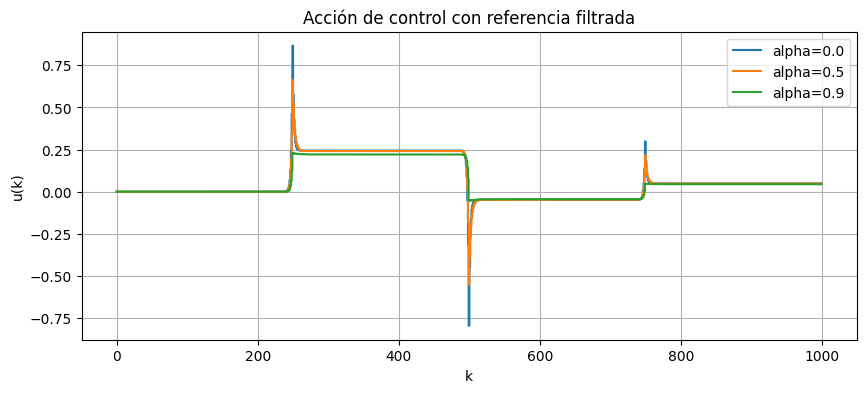

In [ ]:
alpha_values = [0.0, 0.5, 0.9]

plt.figure(figsize=(10, 4))
plt.plot(k_y, ref, label="Referencia")

for alpha in alpha_values:
    y_test, _ = simulate_mac(
        Ad, Bd, Cd, Dd,
        hi=hi,
        horizon=horizon,
        lam=lam,
        ref=ref,
        alpha=alpha
    )
    plt.plot(k_y, y_test, label=f"alpha={alpha}")

plt.xlabel("k")
plt.ylabel("y(k)")
plt.title("Efecto del filtrado de referencia")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))

for alpha in alpha_values:
    _, u_test = simulate_mac(
        Ad, Bd, Cd, Dd,
        hi=hi,
        horizon=horizon,
        lam=lam,
        ref=ref,
        alpha=alpha
    )
    plt.step(k_u, u_test, where="post", label=f"alpha={alpha}")

plt.xlabel("k")
plt.ylabel("u(k)")
plt.title("Acción de control con referencia filtrada")
plt.grid(True)
plt.legend()
plt.show()


### Preguntas para dinamizar — filtrado de la referencia

> **Pregunta 54.** ¿Qué representa físicamente $\alpha$ en el filtro de referencia?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Determina cuánto peso se da a la trayectoria filtrada anterior frente al nuevo valor de referencia:

\begin{align*}
w(k+j)=
\alpha w(k+j-1)
+
(1-\alpha)r(k+j).
\end{align*}

Cuando $\alpha$ es grande, la trayectoria interna cambia lentamente. Cuando $\alpha$ es pequeño, se aproxima más rápidamente a la referencia real.

</details>

> **Pregunta 55.** ¿Qué ocurre en el caso $\alpha=0$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

La ecuación queda

\begin{align*}
w(k+j)=r(k+j),
\end{align*}

por lo que no existe suavizado: la referencia interna coincide directamente con la referencia futura.

Conceptualmente equivale al MAC sin filtrado, siempre que se utilice la misma indexación de referencia.

</details>

> **Pregunta 56.** ¿Qué ocurriría si $\alpha$ fuese muy próximo a 1?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

La referencia interna avanzaría muy lentamente hacia el nuevo valor.

La acción de control sería normalmente más suave y sus picos disminuirían, pero el seguimiento sería más lento.

</details>

> **Pregunta 57.** ¿Es equivalente aumentar $\alpha$ a aumentar $\lambda$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No.

Ambos pueden suavizar la acción, pero actúan en lugares diferentes:

- $\alpha$ modifica la **trayectoria de referencia** que se desea seguir;
- $\lambda$ modifica la **función objetivo**, penalizando directamente la magnitud de $u$.

Por tanto, aunque algunas curvas puedan parecer similares, el mecanismo de diseño es distinto.

</details>


In [ ]:
# Cuantificación del efecto de alpha

print("alpha       max|u|       error_ss(r=0.5)")
print("-----------------------------------------")

for alpha in alpha_values:
    y_test, u_test = simulate_mac(
        Ad, Bd, Cd, Dd,
        hi=hi,
        horizon=horizon,
        lam=lam,
        ref=ref,
        alpha=alpha
    )

    e_ss = np.mean(ref[2*q-50:2*q] - y_test[2*q-50:2*q])

    print(
        f"{alpha:5.2f}      "
        f"{np.max(np.abs(u_test)):10.5f}      "
        f"{e_ss:+16.8f}"
    )


alpha       max|u|       error_ss(r=0.5)
-----------------------------------------
 0.00         0.86643           +0.02103888
 0.50         0.66187           +0.02456778
 0.90         0.22858           +0.06096174



## 14. Experimento D — Efecto del horizonte de predicción $h$

Hasta ahora se ha utilizado

\begin{align*}
h=10.
\end{align*}

El horizonte indica cuántas muestras futuras se consideran al optimizar.

> **Pregunta 58.** ¿Qué esperáis que ocurra si reducimos mucho $h$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

El controlador dispone de menos información sobre las consecuencias futuras de sus acciones.

Puede volverse más miope y perder capacidad de anticipación. Esto resulta especialmente importante cuando la planta tiene dinámica lenta o tiempo muerto.

</details>

> **Pregunta 59.** ¿Aumentar $h$ mejora siempre el comportamiento?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No necesariamente.

Una vez que el horizonte cubre suficientemente la dinámica relevante, aumentarlo puede aportar poca mejora mientras aumenta:

- el tamaño de $G$;
- el número de variables de decisión;
- el coste computacional.

Además, las predicciones lejanas suelen ser menos fiables cuando existe incertidumbre de modelo.

</details>

> **Pregunta 60.** ¿Qué relación conviene mantener entre $h$ y $N_t$ en esta práctica?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

El notebook recomienda mantener

\begin{align*}
h<N_t.
\end{align*}

El modelo FIR debe contener suficiente memoria para construir las predicciones a lo largo del horizonte considerado.

</details>


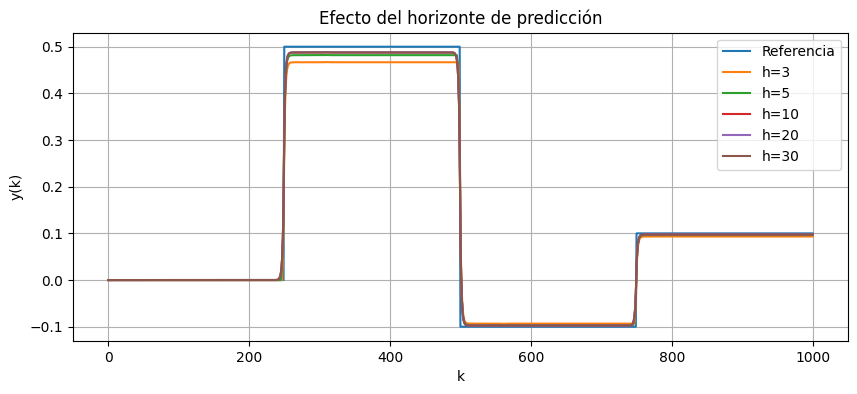


h       max|u|       error_ss(r=0.5)
-------------------------------------
 3         0.87833           +0.03730381
 5         0.86765           +0.02500971
10         0.86643           +0.02103888
20         0.86654           +0.02089786
30         0.86654           +0.02089771


In [ ]:
# Experimento en directo: efecto del horizonte de predicción

h_values = [3, 5, 10, 20, 30]

plt.figure(figsize=(10, 4))
plt.plot(k_y, ref, label="Referencia")

for h_test in h_values:
    if h_test >= Nt:
        print(f"h={h_test}: omitido porque debe mantenerse h < Nt")
        continue

    y_test, _ = simulate_mac(
        Ad, Bd, Cd, Dd,
        hi=hi,
        horizon=h_test,
        lam=lam,
        ref=ref
    )
    plt.plot(k_y, y_test, label=f"h={h_test}")

plt.xlabel("k")
plt.ylabel("y(k)")
plt.title("Efecto del horizonte de predicción")
plt.grid(True)
plt.legend()
plt.show()

print("\nh       max|u|       error_ss(r=0.5)")
print("-------------------------------------")

for h_test in h_values:
    if h_test >= Nt:
        continue

    y_test, u_test = simulate_mac(
        Ad, Bd, Cd, Dd,
        hi=hi,
        horizon=h_test,
        lam=lam,
        ref=ref
    )

    e_ss = np.mean(ref[2*q-50:2*q] - y_test[2*q-50:2*q])

    print(
        f"{h_test:2d}      "
        f"{np.max(np.abs(u_test)):10.5f}      "
        f"{e_ss:+16.8f}"
    )



> **Pregunta 61.** Observando las curvas, ¿a partir de qué horizonte consideráis que aumentar $h$ aporta una mejora pequeña para esta planta?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

La respuesta debe basarse en los resultados ejecutados en el notebook, no en un valor universal.

La idea es identificar el punto a partir del cual las curvas de salida y acción de control cambian poco al seguir aumentando $h$. Ese valor constituye una elección razonable desde el compromiso prestaciones–coste computacional.

</details>

> **Pregunta 62.** Si la planta tuviese un tiempo muerto de 15 muestras, ¿sería razonable utilizar $h=10$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No sería una elección adecuada.

Dentro de ese horizonte el controlador apenas llegaría a observar el efecto de las acciones actuales sobre la salida. Sería necesario que el horizonte se extendiese más allá del tiempo muerto y cubriese además una parte significativa de la dinámica posterior.

</details>


## 15. Actividad final

Realice una selección razonada de los parámetros

\begin{align*}
T_d,\qquad N_t,\qquad h,\qquad \lambda,\qquad \alpha
\end{align*}

para el proceso estudiado.

Justifique la elección utilizando al menos:

- calidad del modelo FIR;
- error estacionario;
- esfuerzo de control;
- rapidez de seguimiento;
- coste computacional asociado al horizonte.

### Entregable propuesto

Incluya:

1. valores finales de los parámetros;
2. gráfica de referencia y salida;
3. gráfica de la acción de control;
4. cuantificación del error estacionario;
5. discusión breve de los compromisos encontrados.


### Preguntas de síntesis antes de elegir los parámetros finales

> **Pregunta 63.** ¿Qué parámetros están ligados principalmente al **modelo** y cuáles a la **sintonización del controlador**?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

De forma aproximada:

- $T_d$ y $N_t$ determinan cómo representamos la dinámica discreta y su memoria;
- $h$ determina cuánto futuro utiliza el controlador;
- $\lambda$ define el compromiso entre seguimiento y esfuerzo de control;
- $\alpha$ modifica la trayectoria interna de referencia.

En la práctica no son completamente independientes, pero esta clasificación ayuda a razonar la sintonización.

</details>

> **Pregunta 64.** ¿En qué orden tendría sentido elegirlos?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Una secuencia razonable para esta práctica sería:

1. elegir $T_d$ de acuerdo con la dinámica;
2. obtener la respuesta impulsional;
3. seleccionar $N_t$ para que el error de truncamiento sea pequeño;
4. seleccionar $h$ para cubrir la dinámica relevante sin coste innecesario;
5. ajustar $\lambda$ según seguimiento y esfuerzo de control;
6. utilizar $\alpha$ si interesa suavizar adicionalmente la referencia.

Así se evita intentar corregir con parámetros de sintonización un modelo discretizado o truncado de forma inadecuada.

</details>

> **Pregunta 65.** Si obtenemos mal seguimiento, ¿por qué no deberíamos modificar inmediatamente $\lambda$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque el problema podría estar en el modelo: $T_d$ inadecuado, $N_t$ demasiado corto o un horizonte insuficiente.

Primero conviene comprobar que la predicción representa correctamente la planta. Después tiene sentido ajustar el compromiso de la función objetivo.

</details>
